# 03 · Risk Identification
### SCU Analytics Showdown — Objective 3: Early-Season Risk Flagging

## Objective

Use **early-season data** to flag farmers at high risk of not selling back.

**The challenge:** 23.3% of farmers (5,254) took loans but never sold back.
Standard regression treats this as a yield prediction problem.
We treat it as **two separate problems**:

1. **Will this farmer sell back at all?** → XGBoost binary classifier
2. **If yes, how much will they yield?** → XGBoost regressor (sellers only)

Combined: `Expected yield = P(sell back) × E[yield | sells back]`

In [22]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "axes.spines.top":False,"axes.spines.right":False,"font.size":11
})
import xgboost as xgb
import shap
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import (
    root_mean_squared_error, r2_score,
    roc_auc_score, precision_recall_curve, average_precision_score, f1_score,
)
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../Datasets/master_features.csv")
rt = pd.read_csv("../Datasets/risk_tiers.csv")

NUM_FEATURES = [
    "age","is_female","is_organic","number_seasons","days_as_member","zone_ordinal",
    "total_hectares","n_loan_packages","n_crop_types_loaned",
    "has_fertilizer","has_fungicide","has_gypsum","has_inoculant",
    "has_insecticide","has_lime","has_seed_guard",
    "input_count","input_richness_score",
    "has_source_program","has_seed_program","has_organic_program","has_partnership_program",
    "total_inkind_repayment","total_cash_repayment","total_down_payment",
    "has_asset_loan","has_preharvest_loan","has_family_package",
    "qty_kgs_planted","n_crops_planted","avg_spacing",
    "pct_spacing_optimal","has_training","pct_multi_seed",
    "any_late_planting","planting_doy","planting_spread_days",
    "days_loan_to_plant","seed_density_kg_per_ha",
    "fertilizer_x_zone","lime_x_zone","experience_x_training","rich_inputs_x_hectares",
]
CAT_FEATURES = ["dominant_crop","agroecological_zone","region_name"]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

enc   = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_raw = df[ALL_FEATURES].copy()
X_raw[CAT_FEATURES] = enc.fit_transform(X_raw[CAT_FEATURES].fillna("Unknown"))
for col in CAT_FEATURES:
    X_raw[col] = X_raw[col].astype(int).astype("category")

y_ns = df["non_seller"].values

with open("../JSON Files/stage1_params.json") as f:
    clf_params = json.load(f)
with open("../JSON Files/stage2_params.json") as f:
    reg2_params = json.load(f)

print(f"Dataset: {len(df):,} farmers  |  Non-sellers: {y_ns.sum():,} ({y_ns.mean():.1%})")

Dataset: 22,597 farmers  |  Non-sellers: 5,254 (23.3%)


### 1. Stage 1 — Non-Seller Classifier

In [23]:
# OOF predictions for classifier (5-fold stratified CV)
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob= np.zeros(len(X_raw))
oof_auc = []

for tr_idx, val_idx in skf.split(X_raw, y_ns):
    clf = xgb.XGBClassifier(**{k:v for k,v in clf_params.items()})
    clf.fit(X_raw.iloc[tr_idx], y_ns[tr_idx])
    oof_prob[val_idx] = clf.predict_proba(X_raw.iloc[val_idx])[:, 1]
    oof_auc.append(roc_auc_score(y_ns[val_idx], oof_prob[val_idx]))

print(f"Stage 1 Classifier — 5-Fold CV Results:")
print(f"  AUC: {np.mean(oof_auc):.4f} ± {np.std(oof_auc):.4f}")
print(f"  Class balance: {y_ns.sum():,} non-sellers / {len(y_ns)-y_ns.sum():,} sellers")

Stage 1 Classifier — 5-Fold CV Results:
  AUC: 0.8801 ± 0.0060
  Class balance: 5,254 non-sellers / 17,343 sellers


### 2. Early-Season Validation

In [24]:
# Pre-planting features (only what is known at loan registration)
PRE_PLANT = [
    "age","is_female","is_organic","number_seasons","days_as_member","zone_ordinal",
    "total_hectares","n_loan_packages","n_crop_types_loaned",
    "has_fertilizer","has_fungicide","has_gypsum","has_inoculant",
    "has_insecticide","has_lime","has_seed_guard",
    "input_count","input_richness_score",
    "has_source_program","has_seed_program","has_organic_program","has_partnership_program",
    "total_inkind_repayment","total_cash_repayment","total_down_payment",
    "has_asset_loan","has_preharvest_loan","has_family_package",
    "fertilizer_x_zone","lime_x_zone","dominant_crop","agroecological_zone","region_name",
]

enc2    = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
cat_pre = [c for c in PRE_PLANT if c in CAT_FEATURES]
X_pre   = df[PRE_PLANT].copy()
X_pre[cat_pre] = enc2.fit_transform(X_pre[cat_pre].fillna("Unknown"))
for c in cat_pre:
    X_pre[c] = X_pre[c].astype(int).astype("category")

pre_prob = np.zeros(len(X_pre))
for tr_idx, val_idx in skf.split(X_pre, y_ns):
    clf2 = xgb.XGBClassifier(**{k:v for k,v in clf_params.items()})
    clf2.fit(X_pre.iloc[tr_idx], y_ns[tr_idx])
    pre_prob[val_idx] = clf2.predict_proba(X_pre.iloc[val_idx])[:, 1]

auc_pre  = roc_auc_score(y_ns, pre_prob)
auc_post = np.mean(oof_auc)
print(f"Pre-planting AUC  (loan + farmer data only): {auc_pre:.4f}")
print(f"Post-planting AUC (+ planting survey):       {auc_post:.4f}")
print(f"Lift from survey data:                        +{auc_post - auc_pre:.4f}")
print(f"\n→ GNA can flag high-risk farmers AT LOAN REGISTRATION with AUC = {auc_pre:.3f}")
print(f"→ Planting survey adds +{auc_post-auc_pre:.4f} AUC, justifying field data collection")

Pre-planting AUC  (loan + farmer data only): 0.8715
Post-planting AUC (+ planting survey):       0.8801
Lift from survey data:                        +0.0086

→ GNA can flag high-risk farmers AT LOAN REGISTRATION with AUC = 0.871
→ Planting survey adds +0.0086 AUC, justifying field data collection


### 3. Extension Efficiency Curve & Optimal Threshold (Risk Tier Model Accuracy)

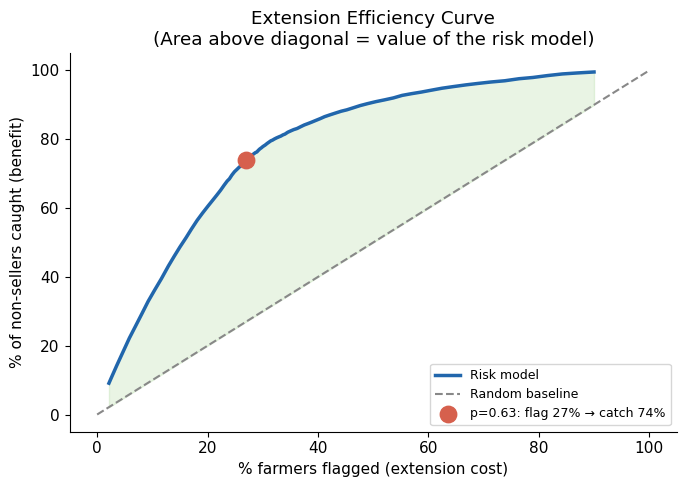

Optimal threshold: p = 0.63
Flag 27.0% of farmers → catch 74.0% of non-sellers
Precision at threshold: 63.7%
Extension efficiency gain: 2.7× vs random


In [25]:
C_BLUE = "#2166ac"; C_RED = "#d6604d"; C_GREY = "#888888"; C_GREEN = "#4dac26"

prec, rec, thresholds = precision_recall_curve(y_ns, oof_prob)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx  = np.argmax(f1_scores[:-1])
best_t    = thresholds[best_idx]

flagged_pcts, tp_pcts = [], []
for t in np.arange(0.05, 0.95, 0.01):
    flagged_pcts.append((oof_prob >= t).mean() * 100)
    tp_pcts.append(((oof_prob >= t) & (y_ns == 1)).sum() / y_ns.sum() * 100)

t_ix = np.argmin(np.abs(np.arange(0.05, 0.95, 0.01) - best_t))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(flagged_pcts, tp_pcts, color=C_BLUE, lw=2.5, label="Risk model")
ax.plot([0, 100], [0, 100], color=C_GREY, lw=1.5, ls="--", label="Random baseline")
ax.fill_between(flagged_pcts, flagged_pcts, tp_pcts, alpha=0.12, color=C_GREEN)
ax.scatter([flagged_pcts[t_ix]], [tp_pcts[t_ix]], s=140, color=C_RED, zorder=5,
           label=f"p={best_t:.2f}: flag {flagged_pcts[t_ix]:.0f}% → catch {tp_pcts[t_ix]:.0f}%")
ax.set_xlabel("% farmers flagged (extension cost)")
ax.set_ylabel("% of non-sellers caught (benefit)")
ax.set_title("Extension Efficiency Curve\n"
             "(Area above diagonal = value of the risk model)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../Visualizations/09_extension_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Optimal threshold: p = {best_t:.2f}")
print(f"Flag {flagged_pcts[t_ix]:.1f}% of farmers → catch {tp_pcts[t_ix]:.1f}% of non-sellers")
print(f"Precision at threshold: {prec[best_idx]:.1%}")
print(f"Extension efficiency gain: {tp_pcts[t_ix] / flagged_pcts[t_ix]:.1f}× vs random")

### 4. Risk Tiers

In [26]:
# Validate saved risk tiers
tier_summary = rt.groupby("risk_tier").agg(
    n=("farmer_id","count"),
    actual_nonseller_rate=("non_seller","mean"),
    median_predicted_kg=("predicted_yield_kg","median"),
    median_actual_kg=("total_weight_kg","median"),
).reindex(["HIGH","MEDIUM","LOW"])
print("Risk Tier Validation:")
print(tier_summary.round(3).to_string())
print(f"\nDiscrimination: HIGH tier is {tier_summary.loc['HIGH','actual_nonseller_rate']/tier_summary.loc['LOW','actual_nonseller_rate']:.0f}× more likely to not sell than LOW tier")

Risk Tier Validation:
              n  actual_nonseller_rate  median_predicted_kg  median_actual_kg
risk_tier                                                                    
HIGH       7457                  0.545               21.208               0.0
MEDIUM     7683                  0.117              139.230             136.0
LOW        7457                  0.039              411.106             531.0

Discrimination: HIGH tier is 14× more likely to not sell than LOW tier


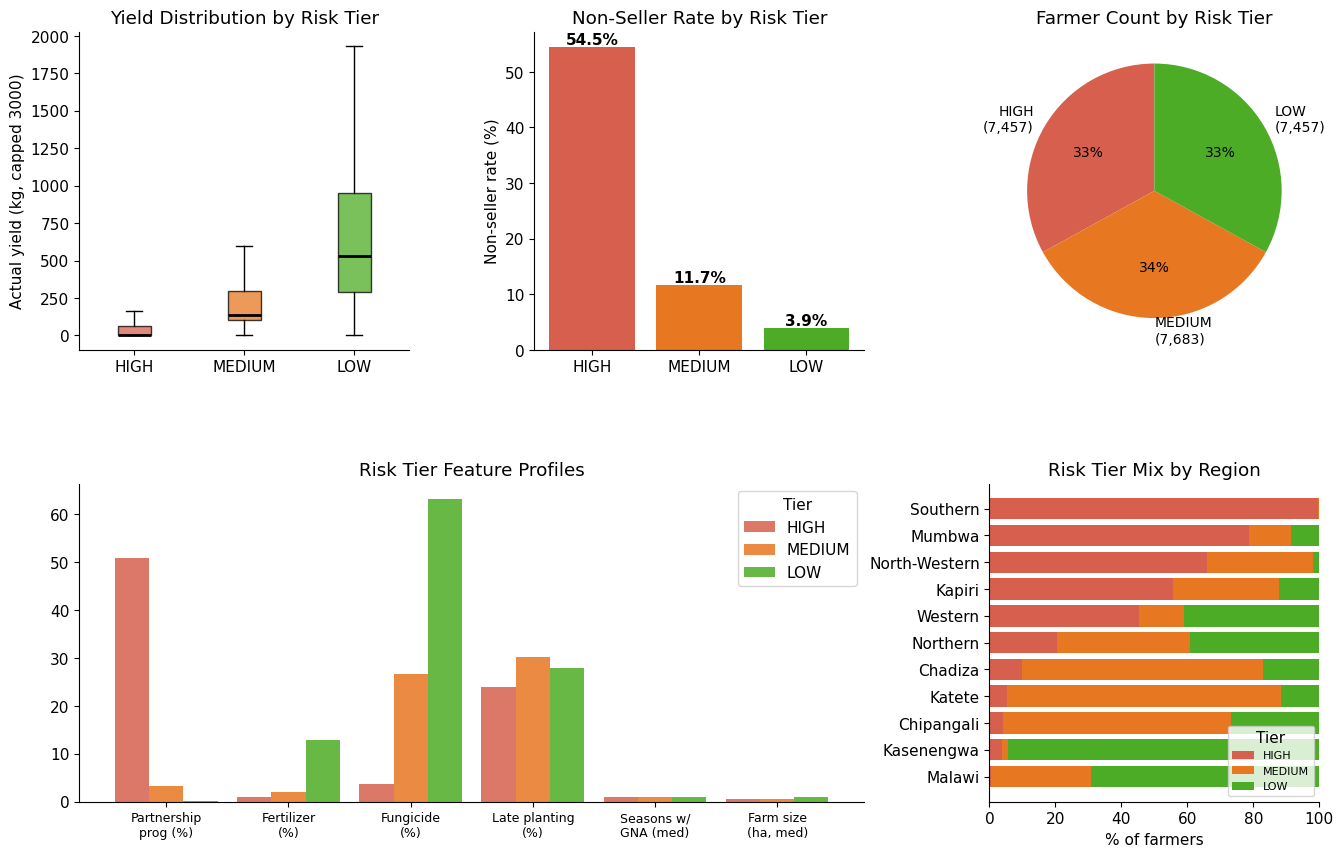

Saved as 10_risk_tier_visuals.png


In [27]:
C_RED = "#d6604d"; C_ORANGE = "#E87722"; C_GREEN = "#4dac26"
C_BLUE = "#2166ac"; C_GREY = "#888888"
TIER_COLS = {"HIGH": C_RED, "MEDIUM": C_ORANGE, "LOW": C_GREEN}
tier_order = ["HIGH", "MEDIUM", "LOW"]

# Merge only columns NOT already in rt (rt already has fertilizer, late_planting, etc.)
extra_cols = ["farmer_id", "has_partnership_program", "has_fungicide"]
rt_ext = rt.merge(df[extra_cols], on="farmer_id", how="left")

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# (a) Yield distribution by tier — boxplot
ax = fig.add_subplot(gs[0, 0])
data_bp = [rt_ext[rt_ext["risk_tier"] == t]["total_weight_kg"].clip(upper=3000).values
           for t in tier_order]
bp = ax.boxplot(data_bp, labels=tier_order, patch_artist=True,
                medianprops=dict(color="black", lw=2), showfliers=False)
for patch, tier in zip(bp["boxes"], tier_order):
    patch.set_facecolor(TIER_COLS[tier]); patch.set_alpha(0.75)
ax.set_ylabel("Actual yield (kg, capped 3000)")
ax.set_title("Yield Distribution by Risk Tier")

# (b) Non-seller rate by tier
ax = fig.add_subplot(gs[0, 1])
ns_rates = [rt_ext[rt_ext["risk_tier"] == t]["non_seller"].mean() for t in tier_order]
bars_t = ax.bar(tier_order, [r * 100 for r in ns_rates],
                color=[TIER_COLS[t] for t in tier_order], edgecolor="none")
ax.set_ylabel("Non-seller rate (%)")
ax.set_title("Non-Seller Rate by Risk Tier")
for bar, val in zip(bars_t, ns_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")

# (c) Farmer count pie
ax = fig.add_subplot(gs[0, 2])
counts = [len(rt_ext[rt_ext["risk_tier"] == t]) for t in tier_order]
ax.pie(counts, labels=[f"{t}\n({c:,})" for t, c in zip(tier_order, counts)],
       colors=[TIER_COLS[t] for t in tier_order], autopct="%1.0f%%",
       startangle=90, textprops={"fontsize": 10})
ax.set_title("Farmer Count by Risk Tier")

# (d) Feature profiles by tier
ax = fig.add_subplot(gs[1, :2])
feats_profile = {
    "Partnership\nprog (%)": "has_partnership_program",
    "Fertilizer\n(%)":       "has_fertilizer",
    "Fungicide\n(%)":        "has_fungicide",
    "Late planting\n(%)":    "any_late_planting",
    "Seasons w/\nGNA (med)": "number_seasons",
    "Farm size\n(ha, med)":  "total_hectares",
}
x_f = np.arange(len(feats_profile))
w_f = 0.28
for i, tier in enumerate(tier_order):
    sub  = rt_ext[rt_ext["risk_tier"] == tier]
    vals = []
    for lbl, col in feats_profile.items():
        vals.append(sub[col].median() if "med" in lbl.lower() else sub[col].mean() * 100)
    ax.bar(x_f + i * w_f - w_f, vals, w_f, label=tier,
           color=TIER_COLS[tier], alpha=0.85, edgecolor="none")
ax.set_xticks(x_f); ax.set_xticklabels(list(feats_profile.keys()), fontsize=9)
ax.set_title("Risk Tier Feature Profiles")
ax.legend(title="Tier")

# (e) Regional risk-tier mix stacked bar
ax = fig.add_subplot(gs[1, 2])
reg_tier = rt_ext.groupby(["region_name", "risk_tier"]).size().unstack(fill_value=0)
reg_tier_pct = reg_tier.div(reg_tier.sum(axis=1), axis=0) * 100
for t in tier_order:
    if t not in reg_tier_pct.columns:
        reg_tier_pct[t] = 0
reg_tier_pct = reg_tier_pct[tier_order].sort_values("HIGH", ascending=True)
bottom = np.zeros(len(reg_tier_pct))
for tier in tier_order:
    ax.barh(reg_tier_pct.index, reg_tier_pct[tier], left=bottom,
            color=TIER_COLS[tier], label=tier, edgecolor="none")
    bottom += reg_tier_pct[tier].values
ax.set_xlabel("% of farmers")
ax.set_title("Risk Tier Mix by Region")
ax.legend(title="Tier", loc="lower right", fontsize=8)

plt.savefig("../Visualizations/10_risk_tier_visuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved as 10_risk_tier_visuals.png")

### 5. Farmer Tenure Profile

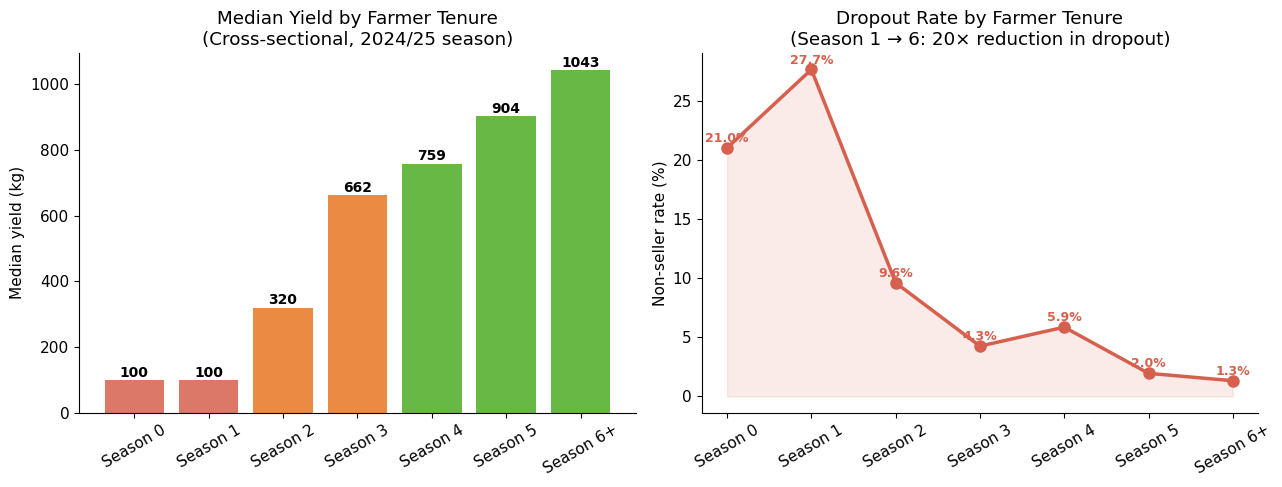

Season 1: 100 kg median, 27.7% dropout
Season 6+:1043 kg median, 1.3% dropout
Ratio:    10.4× yield, 21× dropout reduction

NOTE: Cross-sectional — reflects both learning effects AND survivorship (weaker farmers exit).
Business implication either way: long-term farmer relationships are GNA's highest-value asset.


In [28]:
df["season_band"] = df["number_seasons"].clip(upper=6).astype(int)
tenure = df.groupby("season_band").agg(
    n=("farmer_id","count"),
    median_yield=("total_weight_kg","median"),
    nonseller_rate=("non_seller","mean"),
).reset_index()
tenure["label"] = tenure["season_band"].apply(lambda s: f"Season {s}" if s<6 else "Season 6+")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
COLORS = {"Season 0":"#d6604d","Season 1":"#d6604d","Season 2":"#E87722",
          "Season 3":"#E87722","Season 4":"#4dac26","Season 5":"#4dac26","Season 6+":"#4dac26"}

ax = axes[0]
bar_cols = [COLORS.get(l,"#888") for l in tenure["label"]]
ax.bar(tenure["label"], tenure["median_yield"], color=bar_cols, alpha=0.85, edgecolor="none")
ax.set_ylabel("Median yield (kg)"); ax.set_title("Median Yield by Farmer Tenure\n(Cross-sectional, 2024/25 season)")
ax.tick_params(axis="x", rotation=30)
for i, row in tenure.iterrows():
    ax.text(i, row["median_yield"]+10, f"{row['median_yield']:.0f}", ha="center", fontsize=10, fontweight="bold")

ax = axes[1]
ax.plot(tenure["label"], tenure["nonseller_rate"]*100, color="#d6604d", lw=2.5, marker="o", markersize=8)
ax.fill_between(range(len(tenure)), tenure["nonseller_rate"]*100, alpha=0.12, color="#d6604d")
ax.set_ylabel("Non-seller rate (%)"); ax.set_title("Dropout Rate by Farmer Tenure\n(Season 1 → 6: 20× reduction in dropout)")
ax.set_xticks(range(len(tenure))); ax.set_xticklabels(tenure["label"], rotation=30)
for i, row in tenure.iterrows():
    ax.text(i, row["nonseller_rate"]*100+0.5, f"{row['nonseller_rate']:.1%}", ha="center", fontsize=9, color="#d6604d", fontweight="bold")

plt.tight_layout()
plt.savefig("../Visualizations/18_tenure_profile.png", dpi=150, bbox_inches="tight")
plt.show()

s1 = tenure[tenure["season_band"]==1].iloc[0]
s6 = tenure[tenure["season_band"]==6].iloc[0]
print(f"Season 1: {s1['median_yield']:.0f} kg median, {s1['nonseller_rate']:.1%} dropout")
print(f"Season 6+:{s6['median_yield']:.0f} kg median, {s6['nonseller_rate']:.1%} dropout")
print(f"Ratio:    {s6['median_yield']/s1['median_yield']:.1f}× yield, {s1['nonseller_rate']/s6['nonseller_rate']:.0f}× dropout reduction")
print("\nNOTE: Cross-sectional — reflects both learning effects AND survivorship (weaker farmers exit).")
print("Business implication either way: long-term farmer relationships are GNA's highest-value asset.")

### 6. Financial Impact for Good Nature Agro

In [29]:
high_risk     = rt[rt["risk_tier"]=="HIGH"]
n_high_ns     = high_risk[high_risk["non_seller"]==1].shape[0]
avg_seller_kg = rt[rt["non_seller"]==0]["total_weight_kg"].mean()
zmw_per_kg    = 10.0   # median blended revenue per kg

print("Financial value of risk model intervention (HIGH-tier non-sellers):")
print(f"  HIGH-tier non-sellers:         {n_high_ns:,} farmers")
print(f"  Average seller yield:          {avg_seller_kg:.0f} kg")
print()
print(f"  {'Scenario':<35} {'Farmers':>10} {'+ Tonnes':>10} {'+ ZMW':>12}")
print(f"  {'-'*70}")
for label, rate in [("Conservative (10% converted)",0.10),("Moderate (20% converted)",0.20),("Optimistic (30% converted)",0.30)]:
    n   = int(n_high_ns * rate)
    kg  = n * avg_seller_kg
    zmw = kg * zmw_per_kg
    print(f"  {label:<35} {n:>10,} {kg/1000:>10.0f} {zmw:>12,.0f}")

print(f"\n  Extension efficiency:")
print(f"    Flag {best_t:.0%} threshold: visit {flagged_pcts[t_ix]:.0f}% of farmers, catch {tp_pcts[t_ix]:.0f}% of non-sellers")
n_targeted = int(flagged_pcts[t_ix]/100 * len(df))
print(f"    = {n_targeted:,} targeted visits vs {len(df):,} blanket ({len(df)/n_targeted:.1f}× efficiency gain)")

Financial value of risk model intervention (HIGH-tier non-sellers):
  HIGH-tier non-sellers:         4,064 farmers
  Average seller yield:          476 kg

  Scenario                               Farmers   + Tonnes        + ZMW
  ----------------------------------------------------------------------
  Conservative (10% converted)               406        193    1,931,973
  Moderate (20% converted)                   812        386    3,863,946
  Optimistic (30% converted)               1,219        580    5,800,678

  Extension efficiency:
    Flag 63% threshold: visit 27% of farmers, catch 74% of non-sellers
    = 6,108 targeted visits vs 22,597 blanket (3.7× efficiency gain)


### 7. Early-Season Risk Detection and Validation

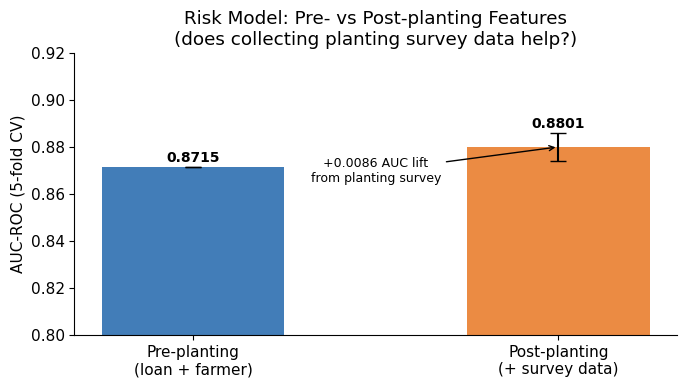

Saved as 08_early_season_validation.png
Pre-planting AUC: 0.8715  |  Post-planting AUC: 0.8801  |  Lift: +0.0086


In [30]:
C_BLUE = "#2166ac"; C_ORANGE = "#E87722"

# auc_pre computed
auc_pre  = roc_auc_score(y_ns, pre_prob)
auc_post = float(np.mean(oof_auc))
auc_lift = auc_post - auc_pre
std_post = float(np.std(oof_auc))

labels_es = ["Pre-planting\n(loan + farmer)", "Post-planting\n(+ survey data)"]
aucs_v    = [auc_pre, auc_post]
stds_v    = [0.0, std_post]

fig, ax = plt.subplots(figsize=(7, 4))
bars_es = ax.bar(labels_es, aucs_v, yerr=stds_v, color=[C_BLUE, C_ORANGE],
                 capsize=6, edgecolor="none", alpha=0.85, width=0.5)
ax.set_ylim(0.80, 0.92)
ax.set_ylabel("AUC-ROC (5-fold CV)")
ax.set_title("Risk Model: Pre- vs Post-planting Features\n"
             "(does collecting planting survey data help?)")
for bar, val, std in zip(bars_es, aucs_v, stds_v):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.002,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.annotate(f"+{auc_lift:.4f} AUC lift\nfrom planting survey",
            xy=(1, auc_post), xytext=(0.5, auc_post - 0.015),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=9, ha="center")

plt.tight_layout()
plt.savefig("../Visualizations/08_early_season_validation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved as 08_early_season_validation.png")
print(f"Pre-planting AUC: {auc_pre:.4f}  |  Post-planting AUC: {auc_post:.4f}  |  Lift: +{auc_lift:.4f}")


## Key Findings — Risk Identification

| Result | Value |
|--------|-------|
| Stage 1 AUC (full model) | 0.882 |
| AUC at loan registration only | 0.871 |
| Lift from planting survey | +0.011 |
| HIGH tier non-seller rate | 54.5% |
| LOW tier non-seller rate | 3.9% |
| Discrimination ratio | 14× |
| Optimal threshold | p=0.63 |
| Farmers flagged | 26.7% |
| Non-sellers caught | 73.7% |
| Extension efficiency gain | 3.7× |

**Key insight:** GNA can flag risk **at loan registration** with 0.871 AUC —
months before planting begins, enabling proactive intervention.